In [6]:
import hbsir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
hbsir.setup(years="1395-1400",method="download_cleaned",download_source="mirror")

In [7]:
import yaml

def extract_table_names(yaml_file_path):
    with open(yaml_file_path, 'r', encoding='utf-8') as file:
        schema = yaml.safe_load(file)

    table_names = set()

    # Extract top-level tables (direct keys)
    for key in schema.keys():
        if isinstance(schema[key], dict) and 'instructions' in schema[key]:
            table_names.add(key)

    # Extract tables from table_list sections
    for section in schema.values():
        if isinstance(section, dict) and 'table_list' in section:
            table_list = section['table_list']
            if isinstance(table_list, dict):
                for tables in table_list.values():
                    if isinstance(tables, list):
                        table_names.update(tables)
                    elif isinstance(tables, str):
                        table_names.add(tables)
            elif isinstance(table_list, list):
                table_names.update(table_list)

    # Remove None if present and sort alphabetically
    table_names.discard(None)
    return sorted(table_names)

# Usage example
yaml_file = r'./schema.yaml'
tables = extract_table_names(yaml_file)
print(tables)

['Administrative_Divisions', 'Cash_Incomes', 'Equivalence_Scale', 'Expenditures', 'Imputed_Rent', 'Income_Breakdown', 'Members_Income_Breakdown', 'Members_Total_Income', 'NonCash_Incomes', 'NonCash_Incomes_Excluding_Imputed_Rent', 'Number_of_Members', 'Original_Expenditures', 'Original_Outlays', 'Outlays', 'Season', 'Total_Expenditure', 'Total_Income', 'Total_Outlay', 'Weight', '_long_other_income', 'census_month', 'cloth', 'communication', 'durable', 'education', 'employment_income', 'entertainment', 'external.hbsir_weights', 'food', 'furniture', 'home', 'hotel', 'house_specifications', 'household_information', 'investment', 'medical', 'members_properties', 'miscellaneous', 'old_rural_house_specifications', 'old_urban_house_specifications', 'other_income', 'private_employment_income', 'public_employment_income', 'self_employed_income', 'subsidy', 'tobacco', 'transportation']


In [8]:
import os

years = [1395] #, 1396, 1397, 1398, 1399, 1400]
tables = extract_table_names(yaml_file)

for year in years:
    for t in tables:
        try:
            print("Loading year", year)
            table = hbsir.load_table(t, years=year)
            directory_path = f'./csvs data/{t}/{year}'
            os.makedirs(directory_path, exist_ok=True)
            output = os.path.join(directory_path, f'{t}_{year}.csv')
            table.to_csv(output, index=False)
            print("Table", t, "done!")
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            continue

Loading year 1395
Table Administrative_Divisions done!
Loading year 1395


/home/parsa/work/venv/lib/python3.10/site-packages/bssir/data_engine.py:418: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.table[column] = self.table[column].fillna(replacement)


Table Cash_Incomes done!
Loading year 1395
Table Equivalence_Scale done!
Loading year 1395
Table Expenditures done!
Loading year 1395
Table Imputed_Rent done!
Loading year 1395
Table Income_Breakdown done!
Loading year 1395


/home/parsa/work/venv/lib/python3.10/site-packages/bssir/data_engine.py:418: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.table[column] = self.table[column].fillna(replacement)


Table Members_Income_Breakdown done!
Loading year 1395
Table Members_Total_Income done!
Loading year 1395
Table NonCash_Incomes done!
Loading year 1395
Table NonCash_Incomes_Excluding_Imputed_Rent done!
Loading year 1395
Table Number_of_Members done!
Loading year 1395
Table Original_Expenditures done!
Loading year 1395
Table Original_Outlays done!
Loading year 1395
Table Outlays done!
Loading year 1395
Table Season done!
Loading year 1395
Table Total_Expenditure done!
Loading year 1395
Table Total_Income done!
Loading year 1395
Table Total_Outlay done!
Loading year 1395
Table Weight done!
Loading year 1395
Table _long_other_income done!
Loading year 1395
Error processing year 1395: No objects to concatenate
Loading year 1395
Table cloth done!
Loading year 1395
Table communication done!
Loading year 1395
Table durable done!
Loading year 1395
Table education done!
Loading year 1395
Table employment_income done!
Loading year 1395
Table entertainment done!
Loading year 1395
Error processin

In [9]:
def csvfind(tableName , year ):
    return  pd.read_csv('./csvs data/' + tableName +"/"+str(year)+"/"+tableName+"_"+str(year)+".csv")

In [10]:
expenditures_95 = csvfind(tableName="Expenditures", year=1395)

In [11]:

expenditures_95 = hbsir.add_attribute(table=expenditures_95, name='Province',year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="Urban_Rural",year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="County",year_col="Year" ,id_col="ID")


In [12]:
members_properties_95 = csvfind(tableName="members_properties", year=1395)
total_income_95 = csvfind("Total_Income",1395)

In [15]:
head_edu = members_properties_95[members_properties_95["Relationship"] == "Head"][["ID", "Education_Level"]]
hh_income = total_income_95.groupby("ID")["Income"].sum().reset_index()

In [21]:
emp_income_95 = csvfind("employment_income", 1395) # Annual_Net_Income
semp_income_95 = csvfind("self_employed_income", 1395) # Profit
oth_income_95 = csvfind("other_income", 1395)
sub_income_95 = csvfind("subsidy", 1395)
total_income_95 = csvfind("Total_Income", 1395)

In [34]:
emp_income_95[emp_income_95["ID"] == 20001010532].head()

,ID,Member_Number,Employment_Status,Occupation_Code,Industry_Code,Sector,Working_Hours_per_Day,Working_Day_per_Week,Monthly_Gross_Income,Annual_Gross_Income,Monthly_Continuous_Income,Annual_Continuous_Income,Monthly_Temporary_Income,Annual_Temporary_Income,Monthly_Net_Income,Annual_Net_Income,Year,Table_Name


In [35]:
semp_income_95[semp_income_95["ID"] == 20001010532].head()

,ID,Member_Number,Employment_Status,Occupation_Code,Industry_Code,Employment_Type,Is_Agricultural,Working_Hours_per_Day,Working_Day_per_Week,Wage_Cost,Cost_of_Sales,Other_Operating_Costs,Other_Costs,Business_Tax,Sales,Profit,Year,Table_Name


In [36]:
oth_income_95[oth_income_95["ID"] == 20001010532].head()

,ID,Member_Number,Retirement,Rent,Interest,Aid,Home_Production,Transfer,Year,Table_Name
1,20001010532,1,36000000.0,NaN,NaN,NaN,NaN,15000000.0,1395,other_income


In [37]:
sub_income_95[sub_income_95["ID"] == 20001010532].head()

,ID,Member_Number,Number_of_Individuals,Number_of_Payments,Subsidy,Year,Table_Name
1,20001010532,1,1,12,5460000.0,1395,subsidy


In [38]:
total_income_95[total_income_95["ID"] == 20001010532].head()

,Year,ID,Income
18837,1395,20001010532,65460000.0


In [40]:
65460000-(36000000+15000000+5460000)

9000000

In [42]:
a=csvfind("Income_Breakdown", 1395)
a[a["ID"]==20001010532].head()

,Year,ID,Income_Type,Income
81329,1395,20001010532,Cash_Retirement,36000000.0
81330,1395,20001010532,Cash_Subsidy,5460000.0
81331,1395,20001010532,Cash_Transfer,15000000.0
81332,1395,20001010532,NonCash_ImputedRent_Ownership,9000000.0


In [16]:
merged = pd.merge(hh_income, head_edu, on="ID")
merged = merged.where(pd.notnull(merged), "None")
print(merged.head())

            ID       Income Education_Level
0  10001000120   66920000.0            None
1  10001000123   96840000.0            None
2  10001000126  143460000.0            None
3  10001000129   38960000.0            None
4  10001000132  224920000.0            None


In [44]:
from utils import *

merged = pd.merge(get_total_income(1395), head_edu, on="ID")
print(merged.head())
head_edu.head()

            ID       Income Education_Level
0  10001000120   66920000.0             NaN
1  10001000123   96840000.0             NaN
2  10001000126  143460000.0             NaN
3  10001000129   38960000.0             NaN
4  10001000132  224920000.0             NaN


,ID,Education_Level
0,20006016234,NaN
1,20006016225,Primary
4,20012021729,NaN
5,20013024132,NaN
7,20013024134,Unofficial


In [102]:
mean_income_by_edu = merged.groupby("Education_Level")["Income"].mean().sort_values(ascending=False)
print(mean_income_by_edu)


Education_Level
Doctoral                5.440895e+08
Masters                 3.504471e+08
Bachelors               2.777313e+08
Short_Cycle_Tertiary    2.227994e+08
Pre_University          1.672256e+08
Higher_Secondary        1.264121e+08
Lower_Secondary         1.249603e+08
Primary                 1.121033e+08
Unofficial              1.013686e+08
None                    1.002769e+08
Name: Income, dtype: float64


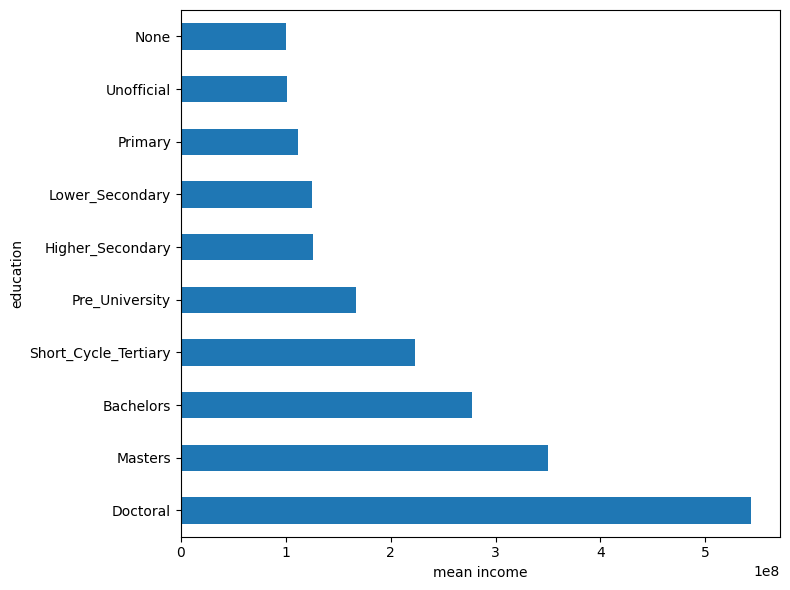

In [103]:
import matplotlib.pyplot as plt

mean_income_by_edu.plot(kind="barh", figsize=(8, 6))
plt.xlabel("mean income")
plt.ylabel("education")
plt.tight_layout()
plt.show()

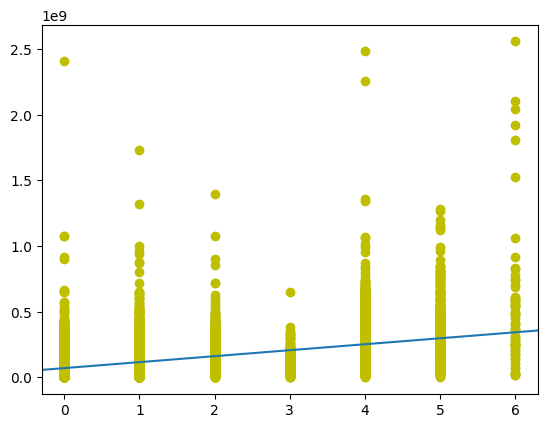

In [104]:
ind = ["None", "Primary", "Lower_Secondary", "Higher_Secondary", "Bachelors", "Masters", "Doctoral"]
appind = lambda x: ind.index(x["Education_Level"]) if ind.count(x["Education_Level"]) > 0 else -1
merged["Edn"] = merged.apply(appind, axis=1)
merged = merged[merged["Edn"] != -1]

m, b = np.polyfit(merged["Edn"], merged["Income"], deg=1)

plt.plot(merged["Edn"], merged["Income"], 'yo')
plt.axline(xy1=(0, b), slope=m, label=f'$y = {m:.1f}x {b:+.1f}$')
plt.show()